# Sentiment Analysis of Dhruv Rathee’s YouTube Video March 29, 5:30 PM

This project analyzes audience sentiment on a political YouTube video using Natural Language Processing (NLP).

## Import Libraries

We import necessary libraries for data handling, visualization, and sentiment analysis.

**Note: Comments might have increased in volume **

import sys
!{sys.executable} -m pip install youtube-comment-downloader --no-cache-dir --default-timeout=100

In [ ]:
from youtube_comment_downloader import YoutubeCommentDownloader

In [1]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
print("VADER imported successfully")

VADER imported successfully


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

## Download Comments from Dhruv Rathee's video 

In [ ]:
url = "https://www.youtube.com/watch?v=SflzVl2UjMM"

downloader = YoutubeCommentDownloader()
comments = []

for c in downloader.get_comments_from_url(url):
    comments.append(c['text'])

df = pd.DataFrame(comments, columns=['comment'])
df.to_csv("comments.csv", index=False)

print("Done. Total comments:", len(df))

## Load the Data

In [6]:
import os
os.getcwd()

'C:\\Users\\arivu\\Documents\\My Manager\\Portfolio\\youtube_sentiment'

In [7]:
df = pd.read_csv("comments.csv")
df.head()

,comment
0,"Make content creation your career, join the co..."
1,"Bhai jitne logon ne Dhurandar nahi dekhi hogi,..."
2,Video pause karke sare comments padh liye..Ac...
3,Mai to dhurandhar2 ka trailer tak nhi dekha😅😅😅😅
4,I like you so much vibes


## Data Cleaning

We clean the text by:
- Converting to lowercase
- Removing special characters and links

In [13]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)   # remove links
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df['clean_comment'] = df['comment'].apply(clean_text)

## Sentiment Analysis

We use analyzer to classify comments into:

In [15]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['clean_comment'].apply(get_sentiment)

## 7 Sentiment Distribution (Markdown + Code)

In [17]:
df['sentiment'].value_counts()

Neutral     39671
Positive    12927
Negative     7146
Name: sentiment, dtype: int64

## Visualization

Bar chart showing sentiment distribution.

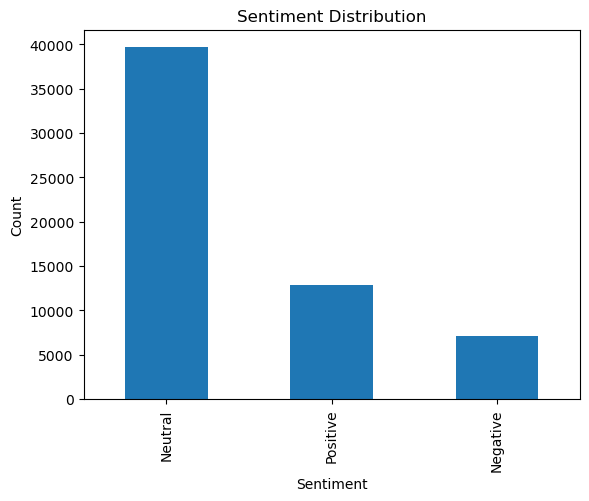

In [16]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()

sentiment_counts.plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## 📊 🔍 Sentiment Distribution — Interpretation

From the chart:

Neutral ≈ 40,000 (highest)
Positive ≈ 13,000
Negative ≈ 7,000

🧠 Key Insight (IMPORTANT)

👉 Unlike expectation (polarized content), the data shows:

Majority of comments are **Neutral, not Positive**

## Comment Length Analysis

We analyze whether longer comments tend to be more negative or positive.

In [18]:
df['comment_length'] = df['comment'].apply(len)
df.groupby('sentiment')['comment_length'].mean()

sentiment
Negative    110.120207
Neutral      44.549898
Positive     90.070937
Name: comment_length, dtype: float64

## ✨ Interpretation

Negative comments are longest
people argue, explain, defend opinions
Positive comments are moderately long
appreciation, agreement
Neutral comments are shortest
low engagement, passive reactions

Emotional intensity drives engagement length

Negative → high emotional investment → longer comments
Neutral → low effort → short comments

## Key Insights

- The majority of comments are classified as neutral, likely due to limitations of sentiment analysis models in detecting subtle or contextual emotions.
- Positive comments form the second largest group, indicating audience support.
- Negative comments, while fewer, represent a significant portion of engagement.

## Comment Behavior Analysis

- Negative comments have the highest average length (~110 characters), suggesting more detailed and argumentative responses.
- Positive comments are moderately long (~90 characters), reflecting appreciation and agreement.
- Neutral comments are shortest (~44 characters), indicating low engagement.

## Conclusion

The analysis shows that while most comments appear neutral, deeper engagement is driven by emotional responses, particularly negative sentiment. This suggests that controversial or opinion-based content generates more detailed audience interaction.